# **Hypothesis 3**
**Null Hypothesis**:
There is no correlation between a students gender and their sentiment on Ai in fields such as therapy and companionship.

**Hypothesis**:
There is a correlation between students gender and their sentiment on Ai in fields such as therapy and companionship.


# Data Implementation and Cleaning

In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("data.csv")

# rename columns
name_dict = {
    'What gender do you identify as?': 'Gender',
    'How beneficial do you see the use of AI in these fields? [Therapists]': 'BenTher',
    'How beneficial do you see the use of AI in these fields? [Companionship]': 'BenComp',
    'In which areas do you find AI helpful in your workflow?  [Personal Advice / Therapy]': 'HelpTher',
    'In which areas do you find AI helpful in your workflow?  [Companionship]': 'HelpComp'
}
df = df.rename(columns=name_dict)

# specific columns for hypothesis 3
df_trim = df[['Gender', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']].copy()

# clean sentiment cols
sent_cols = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']
for col in sent_cols: df_trim[col] = df_trim[col].astype(str).str.extract(r'(\d+)').astype(float)

# drop missing data
df_trim = df_trim.dropna()

# add Gender_Num column for correlation: Male 0, Female 1, other 2
gendermap = {'Male': 0, 'Female': 1}
df_trim['Gender_Num'] = df_trim['Gender'].map(gendermap).fillna(2).astype(int)

# create average sentiment column
sentiment_cols = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_trim['Average_Sentiment'] = df_trim[sentiment_cols].mean(axis=1)

# Visualization 7 - Correlation Heat Map

Correlation:              Gender_Num   BenTher   BenComp  HelpTher  HelpComp
Gender_Num    1.000000 -0.154003 -0.114914 -0.139424 -0.131512
BenTher      -0.154003  1.000000  0.672241  0.510502  0.459832
BenComp      -0.114914  0.672241  1.000000  0.548089  0.562256
HelpTher     -0.139424  0.510502  0.548089  1.000000  0.825998
HelpComp     -0.131512  0.459832  0.562256  0.825998  1.000000


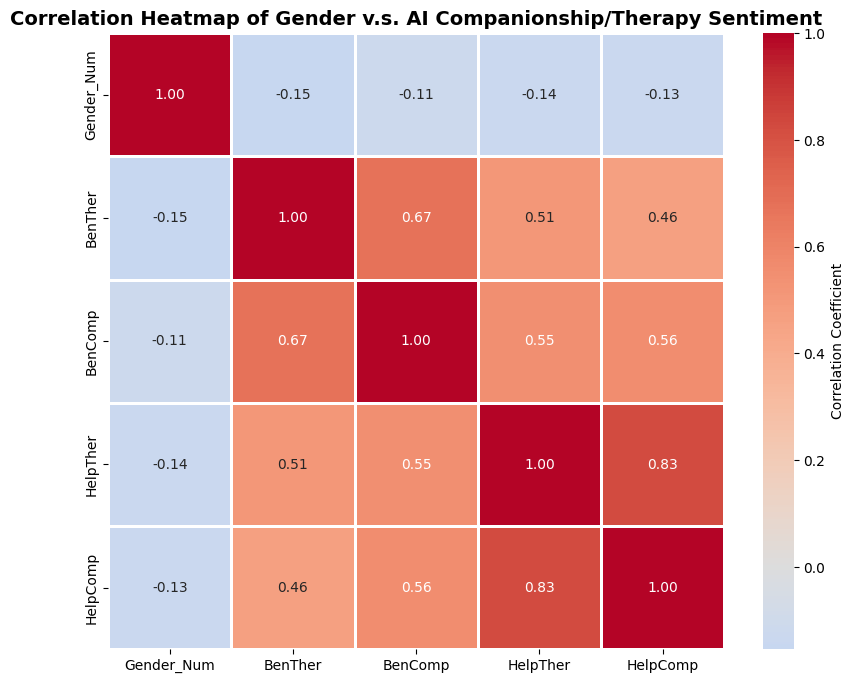

Gender Correlation:               BenTher   BenComp  HelpTher  HelpComp
Gender_Num -0.154003 -0.114914 -0.139424 -0.131512


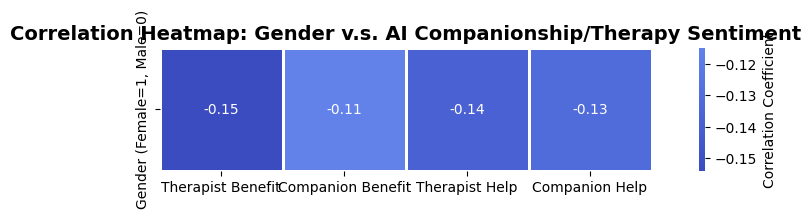

In [ ]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
# numeric_df = df.select_dtypes(include=[np.number])
df_num = df_trim[['Gender_Num', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']]

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
r = df_num.corr()
print(f"Correlation: ", r)

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap of Gender v.s. AI Companionship/Therapy Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

# Create a correlation heatmap to visualize relationships between all numeric variables

# correlation for gender
gender_r = r.loc[['Gender_Num'], ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']]
print(f"Gender Correlation: ", gender_r)

gender_r.index = ['Gender (Female=1, Male=0)']
gender_r.columns = ['Therapist Benefit', 'Companion Benefit', 'Therapist Help', 'Companion Help']

# Set figure size for better readability
plt.figure(figsize=(10, 2))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(gender_r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap: Gender v.s. AI Companionship/Therapy Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

**Correlation Heat Map**:We chose a correlation heatmap for our visualzation because it best shows different correlation values and best represents gender's correlation with the various different therapy and companionship related questions.



**Analysis and Conclusion**:The heatmanp shows very low values for the Pearson correlation coefficient amongst gender and the different columns. Because the values are so close to 0, we are able to identify that there is little to no correlation between gender and sentiment.

## Visualization 8 - Stacked Bar Chart

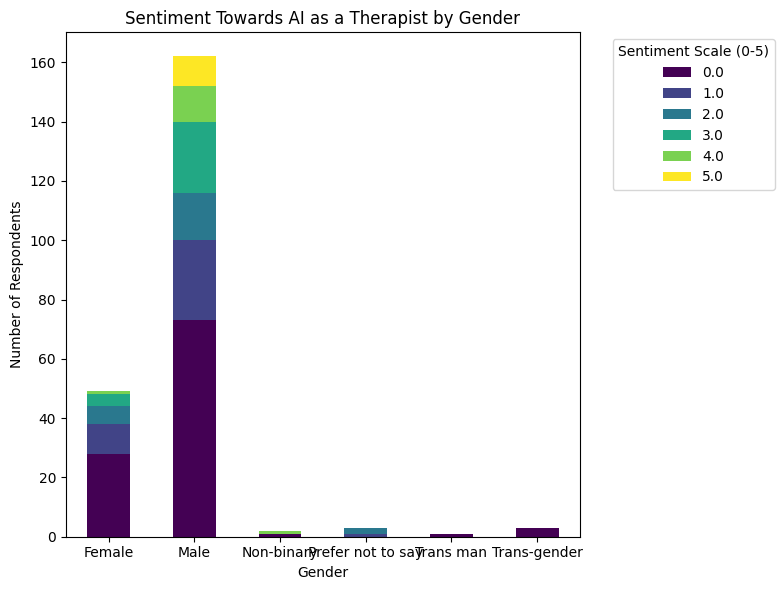

In [ ]:
# cross-tab of Gender vs AI Therapy
crosstab_ther = pd.crosstab(df_trim['Gender'], df_trim['BenTher'])

# plotting
crosstab_ther.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')

plt.title('Sentiment Towards AI as a Therapist by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.legend(title='Sentiment Scale (0-5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Stacked Bar Chart**:
This graph is used to show the proprotion of answers from each of the individual genders.

**Analysis and Conclusion**:
This stacked bar chart shows the count of responses across all answered genders. We can see that there were a much larger count of Male responders meaning that they were possibly overrepresented in the data. While we do see many more counts of high sentient towards therapy and companionship, it seems to be proportional to the female catergory which had many fewer responders.

## Visualization 9 - Violin plot Matrix

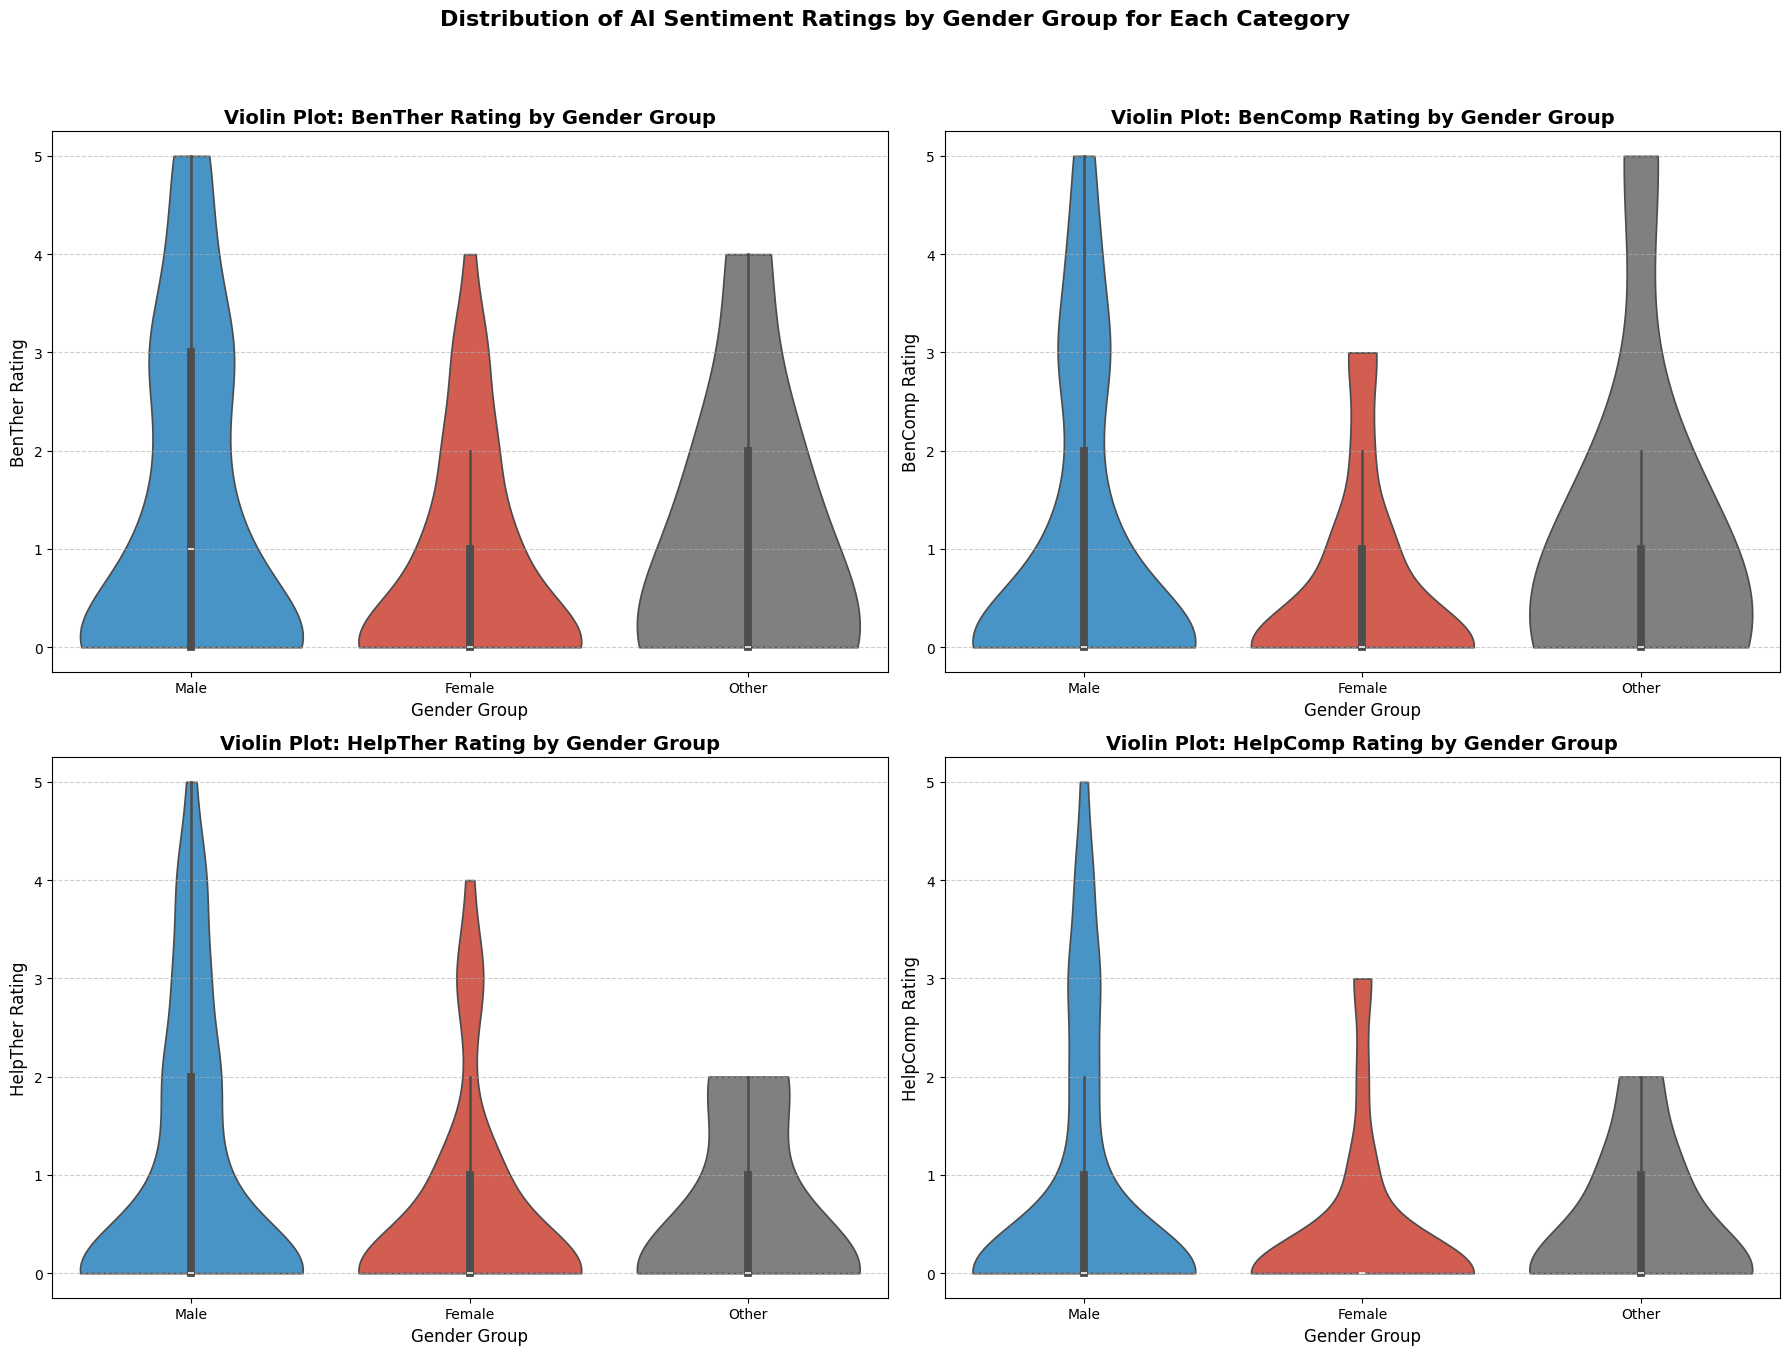

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_trim and Gender_Grouped are already defined from previous cells
# If not, ensure the necessary setup code is run first.

# Define a consistent color palette for gender groups (reusing from previous visualizations)
gender_palette = {'Male': '#3498db', 'Female': '#e74c3c', 'Other': '#808080'} # Blue, Red, Grey

sentiment_columns = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']

fig, axes = plt.subplots(2, 2, figsize=(18, 14)) # Create a new figure and 2x2 subplots
fig.suptitle('Distribution of AI Sentiment Ratings by Gender Group for Each Category', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, col in enumerate(sentiment_columns):
    sns.violinplot(x='Gender_Grouped', y=col, data=df_trim,
                   inner='box', palette=gender_palette, order=['Male', 'Female', 'Other'],
                   hue='Gender_Grouped', legend=False, cut=0, ax=axes[i])

    # Add labels and title
    axes[i].set_xlabel('Gender Group', fontsize=12)
    axes[i].set_ylabel(f'{col} Rating', fontsize=12)
    axes[i].set_title(f'Violin Plot: {col} Rating by Gender Group',
                      fontsize=14, fontweight='bold')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()


**Violin Plot Matrix**:
These violin plots represent the different weights of answers for each of the questions related to the sentiment of AI in theraputic and companionship.

**Analysis and Conclusion**:These graphs show the distrubition of weight between answers of each gendered group. For all the graphs we can see that males have a slightly higher weight on ratings above 3, while females and others are typically returning lower ratings at 3 or lower.

## Chi-Square Test

**Null Hypothesis**: There is no correlation between a students gender and their sentiment on Ai in fields such as therapy and companionship.

**Hypothesis**: There is a correlation between students gender and their sentiment on Ai in fields such as therapy and companionship.

In [ ]:
# create contingency table
contingency_table = pd.crosstab(df_trim['Gender'], df_trim['Average_Sentiment'])

# use contingency to run chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# print statistic
print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: ")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: ")

Chi-Square Statistic: 51.84
P-value: 0.9999

Result: Fail to reject the Null Hypothesis.
Conclusion: 


From our Chi-Square calculation we are forced to accept the null hypothesis in which we find there is no correlation between gender and sentiment towards Ai in companionship and theraputic purposes.